# Sweden population spike map with GeoPandas and Matplotlib

This notebook downloads Statistics Sweden's official 2025 population grid and creates the map **directly in the notebook**. Every spike is plotted with Matplotlib from a 1 km² SCB grid cell.

## Packages

- **Requests** downloads the GeoJSON.
- **GeoPandas** reads the geometry and handles EPSG:3006.
- **pandas** provides tabular inspection through GeoPandas.
- **NumPy** performs vectorised height and colour calculations.
- **Matplotlib** draws the complete map and exports the high-resolution PNG.
- **Pillow** creates a compact WebP copy for the Data Lab home page.

Install them once with the next cell.

In [1]:
# Run this cell once if the packages are not installed.
# pip install "geopandas>=1.0" "matplotlib>=3.8" "numpy>=1.26" "pandas>=2.2" "requests>=2.31" "pillow>=10"

In [2]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from PIL import Image

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.dpi": 140,
})
print("GeoPandas:", gpd.__version__)
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)

GeoPandas: 1.1.4
pandas: 3.0.5
NumPy: 2.5.3


## 1. Download the SCB population grid

SCB publishes registered population on a 1 km grid. We request only total population (`beftotalt`) and geometry (`sp_geometry`) from the 2025 WFS layer, in **SWEREF 99 TM / EPSG:3006**. The 39 MB response is cached locally.

Source: [Statistics Sweden — Grid statistics](https://www.scb.se/en/services/open-data-api/open-geodata/grid-statistics/)

In [3]:
PROJECT_ROOT = next(
    folder for folder in [Path.cwd(), *Path.cwd().parents]
    if (folder / "geo/sweden_population_map").exists()
)
GEO_DIR = PROJECT_ROOT / "geo"
MAP_DIR = GEO_DIR / "sweden_population_map"
DATA_PATH = MAP_DIR / "data/scb_population_1km_2025.geojson"
OUTPUT_PATH = MAP_DIR / "output/sweden_population_2025_matplotlib.png"
HOMEPAGE_PNG = PROJECT_ROOT / "_static/sweden_population_spike_map_2025.png"
HOMEPAGE_WEBP = PROJECT_ROOT / "_static/sweden_population_spike_map_2025.webp"

SCB_WFS_URL = (
    "https://geodata.scb.se/geoserver/stat/wfs"
    "?service=WFS&version=1.1.0&request=GetFeature"
    "&typeName=stat%3Abefolkning_1km_2025"
    "&outputFormat=application%2Fjson&srsName=EPSG%3A3006"
    "&propertyName=beftotalt%2Csp_geometry"
)
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
HOMEPAGE_PNG.parent.mkdir(parents=True, exist_ok=True)

In [4]:
if not DATA_PATH.exists():
    with requests.get(SCB_WFS_URL, stream=True, timeout=180) as response:
        response.raise_for_status()
        with DATA_PATH.open("wb") as output_file:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                output_file.write(chunk)
    print("Downloaded:", DATA_PATH)
else:
    print("Using cached data:", DATA_PATH)

print(f"File size: {DATA_PATH.stat().st_size / 1_000_000:.1f} MB")

Using cached data: /Users/changliu/Documents/data-lab/geo/sweden_population_map/data/scb_population_1km_2025.geojson
File size: 40.5 MB


## 2. Read and inspect the geospatial data

GeoPandas reads every square as a polygon. We keep zero-population cells because they form the pale geographic silhouette. Cell centroids become the spike locations.

In [5]:
grid = gpd.read_file(DATA_PATH)[["beftotalt", "geometry"]]
if grid.crs is None:
    grid = grid.set_crs(3006)
else:
    grid = grid.to_crs(3006)

grid["population"] = pd.to_numeric(grid["beftotalt"], errors="coerce").fillna(0)
centres = grid.geometry.centroid
grid["x"] = centres.x
grid["y"] = centres.y

pd.Series({
    "CRS": str(grid.crs),
    "grid cells": f"{len(grid):,}",
    "inhabited cells": f"{(grid.population > 0).sum():,}",
    "total population": f"{grid.population.sum():,.0f}",
    "largest cell": f"{grid.population.max():,.0f}",
})

CRS                  EPSG:3006
grid cells             115,118
inhabited cells        103,464
total population    10,578,118
largest cell            24,611
dtype: str

Add the län boundaries, see the boundary informaiton data from [the water object notebook](geo_manmade_water_objects.ipynb).

In [6]:
lan_path = GEO_DIR / "shape_svenska_260225/LanSweref99TM.zip"
lan = gpd.read_file(f"zip://{lan_path.resolve()}")

## 3. Define the visual encoding

A linear scale would hide rural variation. The power curve below compresses the range while preserving the order of the actual data. Heights are expressed in map metres because the axes use EPSG:3006.

$$h(p) = \min(65000,\;550 + 700p^{0.43})$$

The colour scale moves from pale lavender to deep magenta. `PowerNorm` exposes variation among smaller places without losing the strongest urban cores.

In [7]:
# --------------------------------------------------
# Convert GeoDataFrame columns to NumPy arrays
# --------------------------------------------------

# x- and y-coordinates of the population grid cells
x = grid.x.to_numpy()
y = grid.y.to_numpy()

# Population value in each grid cell
population = grid.population.to_numpy(dtype=float)


# --------------------------------------------------
# Identify inhabited cells
# --------------------------------------------------

# True where population is larger than 0
inhabited = population > 0

# --------------------------------------------------
# Calculate the visual height of each population spike
# --------------------------------------------------

# Start with zero height everywhere
spike_height = np.zeros_like(population)

# Use a nonlinear transformation:
# - small populations still get visible spikes
# - very large populations do not dominate too much
# - maximum spike height is limited to 65,000 map units
spike_height[inhabited] = np.minimum(
    65_000,
    550 + 700 * population[inhabited] ** 0.43
)

# --------------------------------------------------
# Swedish-inspired colour map
# --------------------------------------------------

# Inspired by Swedish blue and yellow,
# with lighter blue tones between them
population_cmap = LinearSegmentedColormap.from_list(
    "sweden_population", ["#c9c1df", "#b894ca", "#d26a9d", "#b42d72", "#65113f"]
)

# --------------------------------------------------
# Normalise population values for colour mapping
# --------------------------------------------------

# Use the 99.9th percentile instead of the absolute maximum
# so a few extremely populated cells do not control all colours
population_max = np.percentile(
    population[inhabited],
    99.9
)

# PowerNorm makes lower population values more visually distinguishable
population_norm = PowerNorm(
    gamma=0.34,
    vmin=1,
    vmax=population_max
)

# --------------------------------------------------
# Assign a colour to each inhabited spike
# --------------------------------------------------
spike_colours = population_cmap(
    population_norm(
        np.maximum(population[inhabited], 1)
    )
)

# --------------------------------------------------
# Calculate spike width
# --------------------------------------------------

# More populated cells get slightly thicker spikes
# while less populated cells remain thin
relative_population = np.clip( population[inhabited] / population_max, 0, 1)
spike_widths = (0.14 + 0.85 * relative_population ** 0.28)

In [8]:
# Main cities and their preferred label side. Label y-positions are calculated
# automatically below so labels cannot collide in the dense south.
cities = pd.DataFrame(
    [
        ("Kiruna", 728_600, 7_536_700, "left"),
        ("Luleå", 828_200, 7_290_400, "right"),
        ("Umeå", 758_200, 7_089_000, "right"),
        ("Sundsvall", 620_700, 6_918_000, "right"),
        ("Uppsala", 648_700, 6_637_000, "right"),
        ("Stockholm", 674_600, 6_580_700, "right"),
        ("Västerås", 589_000, 6_609_000, "left"),
        ("Örebro", 511_000, 6_570_000, "left"),
        ("Linköping", 535_000, 6_474_000, "right"),
        ("Jönköping", 450_000, 6_401_000, "left"),
        ("Göteborg", 319_900, 6_404_100, "left"),
        ("Helsingborg", 356_300, 6_213_000, "left"),
        ("Malmö", 374_400, 6_169_900, "right"),
    ],
    columns=["name", "x", "y", "side"],
)

def spread_label_positions(values, lower, upper, minimum_gap=43_000):
    """Spread labels vertically while keeping them close to their cities."""
    order = np.argsort(values)
    positioned = np.clip(np.asarray(values, dtype=float)[order], lower, upper)
    for index in range(1, len(positioned)):
        positioned[index] = max(positioned[index], positioned[index - 1] + minimum_gap)
    if len(positioned) and positioned[-1] > upper:
        positioned[-1] = upper
        for index in range(len(positioned) - 2, -1, -1):
            positioned[index] = min(positioned[index], positioned[index + 1] - minimum_gap)
    result = np.empty_like(positioned)
    result[order] = positioned
    return result

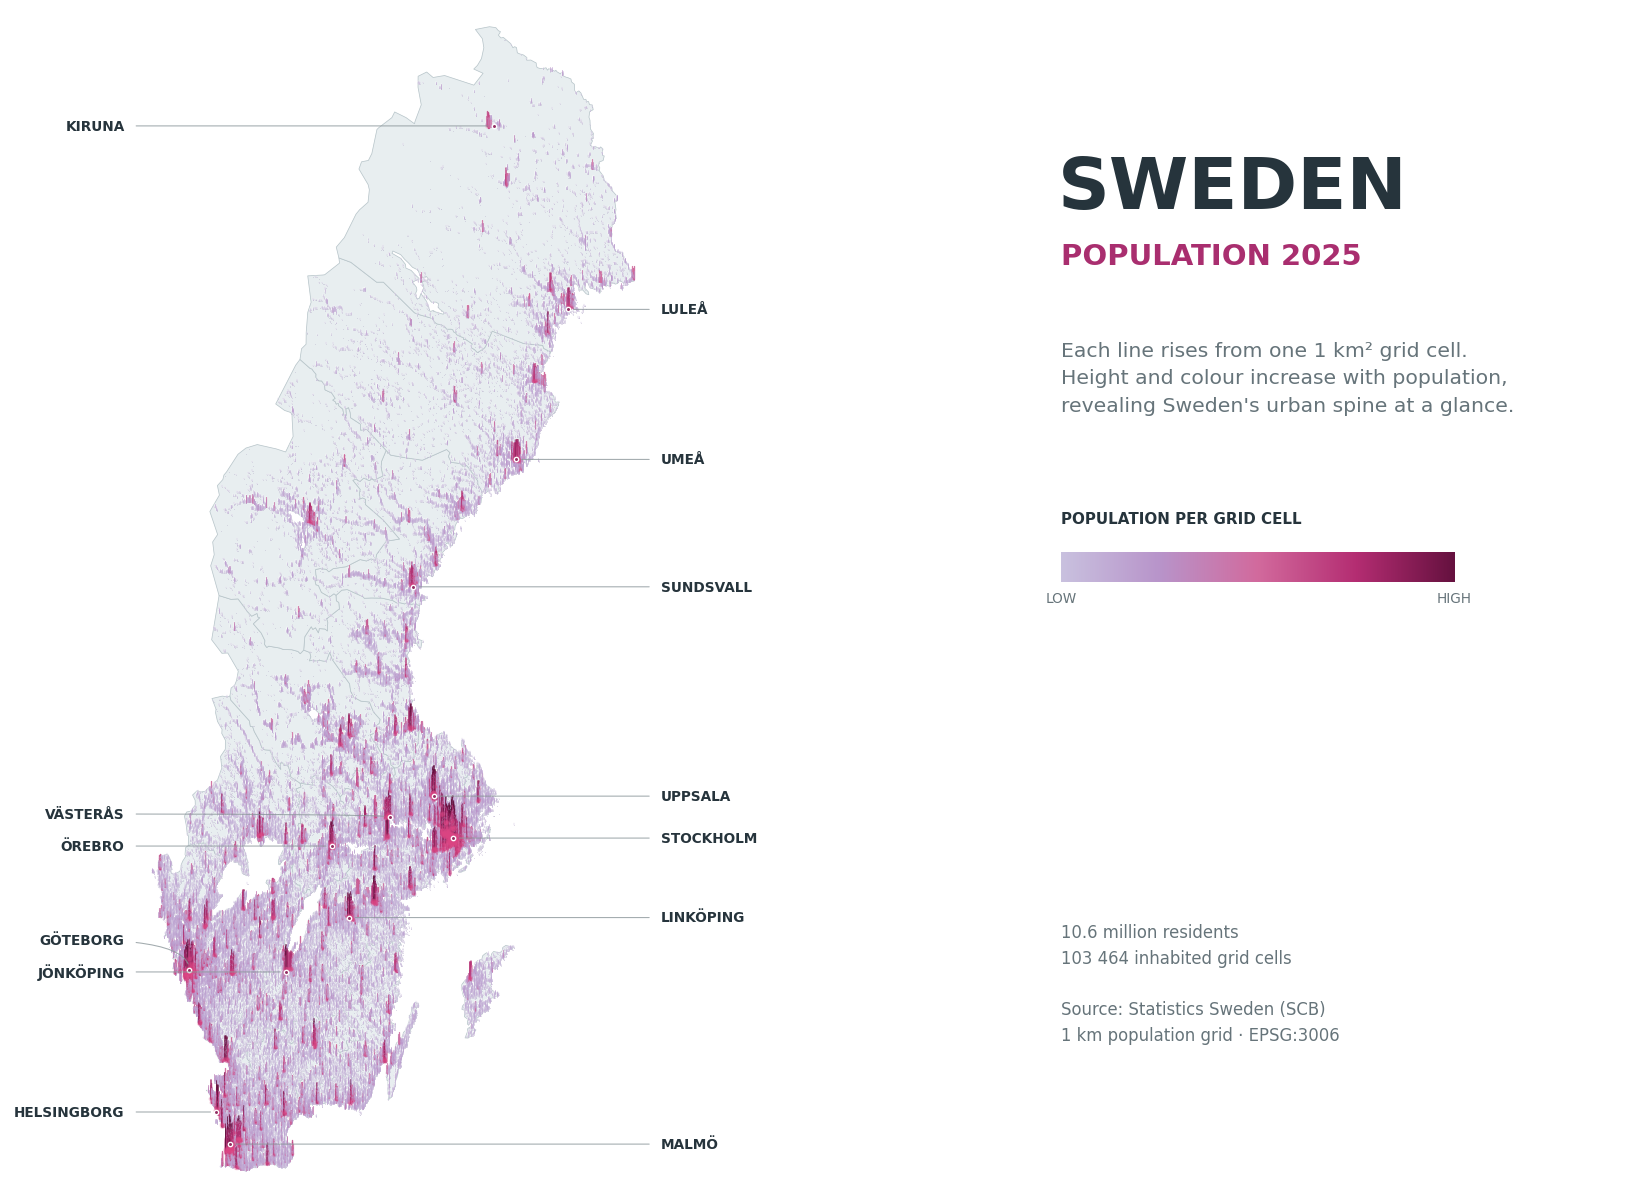

In [35]:
background = "white"
ink = "#26343C"
muted = "#66747A"
fig = plt.figure(figsize=(14, 9), facecolor=background)
layout = fig.add_gridspec(1, 2, width_ratios=(1.55, 0.72), wspace=0.01)
ax = fig.add_subplot(layout[0])
info_ax = fig.add_subplot(layout[1])
info_ax.set_facecolor(background)
ax.set_facecolor(background)

# Editorial title panel for the Data Lab home page.
info_ax.axis("off")
info_ax.text(0.04, 0.88, "SWEDEN", transform=info_ax.transAxes,
             fontsize=37, fontweight="bold", color=ink, va="top")
info_ax.text(0.045, 0.805, "POPULATION 2025", transform=info_ax.transAxes,
             fontsize=15, fontweight="bold", color="#A92E6F", va="top")
info_ax.text(
    0.045, 0.72,
    "Each line rises from one 1 km² grid cell.\n"
    "Height and colour increase with population,\n"
    "revealing Sweden's urban spine at a glance.",
    transform=info_ax.transAxes, fontsize=10.5, color=muted,
    linespacing=1.55, va="top",
)
info_ax.text(0.045, 0.565, "POPULATION PER GRID CELL", transform=info_ax.transAxes,
             fontsize=7.8, fontweight="bold", color=ink)
legend_ax = info_ax.inset_axes([0.045, 0.515, 0.67, 0.025])
gradient = np.linspace(0, 1, 512).reshape(1, -1)
legend_ax.imshow(gradient, aspect="auto", cmap=population_cmap, origin="lower")
legend_ax.set_xticks([0, 511], ["LOW", "HIGH"], fontsize=7, color=muted)
legend_ax.tick_params(axis="x", length=0, pad=5)
legend_ax.set_yticks([])
for spine in legend_ax.spines.values():
    spine.set_visible(False)
info_ax.text(
    0.045, 0.12,
    f"{population.sum() / 1_000_000:.1f} million residents\n"
    f"{inhabited.sum():,} inhabited grid cells".replace(",", " ") +
    "\n\nSource: Statistics Sweden (SCB)\n1 km population grid · EPSG:3006",
    transform=info_ax.transAxes, fontsize=8.5, color=muted,
    linespacing=1.55, va="bottom",
)

# Quiet geographic context: counties, then every 1 km² population cell.
lan.plot(ax=ax, facecolor="#E8EEF0", edgecolor="#B8C5CA", linewidth=0.38, zorder=0)
ax.scatter(x, y, s=0.19, c="#BEB7D0", alpha=0.48, linewidths=0,
           rasterized=True, zorder=1)

spike_segments = np.stack([
    np.column_stack([x[inhabited], y[inhabited]]),
    np.column_stack([x[inhabited], y[inhabited] + spike_height[inhabited]]),
], axis=1)
# A subtle underlay gives the fine spikes depth without hiding rural cells.
ax.add_collection(LineCollection(
    spike_segments, colors="#FFFFFF", linewidths=spike_widths + 0.55,
    alpha=0.25, capstyle="round", rasterized=True, zorder=2,
))
ax.add_collection(LineCollection(
    spike_segments, colors=spike_colours, linewidths=spike_widths,
    alpha=0.82, capstyle="round", rasterized=True, zorder=3,
))

dense = population >= 2_000
ax.scatter(
    x[dense], y[dense],
    s=np.clip((population[dense] / 2_000) ** 0.55 * 4, 3, 18),
    c="#E04A88", alpha=0.16, linewidths=0, rasterized=True, zorder=4,
)

# Collision-free label columns with short leaders back to each city.
min_x, min_y, max_x, max_y = grid.total_bounds
cities = cities.copy()
for side in ("left", "right"):
    mask = cities.side.eq(side)
    cities.loc[mask, "label_y"] = spread_label_positions(
        cities.loc[mask, "y"].to_numpy(), min_y + 22_000, max_y - 18_000
    )
label_x = {"left": min_x - 36_000, "right": max_x + 36_000}
for city in cities.itertuples():
    align = "right" if city.side == "left" else "left"
    ax.scatter(city.x, city.y, s=5, color="#933064", edgecolor=background,
               linewidth=0.7, zorder=6)
    ax.annotate(
        city.name.upper(), xy=(city.x, city.y), xytext=(label_x[city.side], city.label_y),
        textcoords="data", ha=align, va="center", fontsize=7.0,
        fontweight="bold", color=ink, zorder=7,
        arrowprops={
            "arrowstyle": "-", "color": "#8B969A", "lw": 0.55,
            "alpha": 0.8, "shrinkA": 4, "shrinkB": 3,
            "connectionstyle": "angle3,angleA=0,angleB=90",
        },
    )

ax.set_xlim(min_x - 112_000, max_x + 112_000)
ax.set_ylim(min_y - 18_000, max_y + 35_000)
ax.set_aspect("equal")
ax.axis("off")

fig.subplots_adjust(left=0.035, right=0.985, top=0.965, bottom=0.035)
fig.savefig(OUTPUT_PATH, dpi=220, facecolor=background, bbox_inches="tight", pad_inches=0.16)
fig.savefig(HOMEPAGE_PNG, dpi=220, facecolor=background, bbox_inches="tight", pad_inches=0.16)
with Image.open(HOMEPAGE_PNG) as image:
    image.save(HOMEPAGE_WEBP, "WEBP", quality=90, method=6)
plt.show()